In [24]:
from typing import TypedDict,List
from langgraph.graph import StateGraph, END
import chromadb
from sentence_transformers import SentenceTransformer

In [64]:
client = chromadb.Client(
    chromadb.config.Settings(
        persist_directory="memory_db"
    ))
collection = client.get_or_create_collection("personal_memory")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

In [65]:
class MemoryState(TypedDict):
    query: str
    response: str

In [66]:
def store_memory(state: MemoryState):
    query = state["query"]
    if query.lower().startswith("remember"):
        fact = query.replace("remember","").strip()
        embedding = embedding_model.encode(fact).tolist()
        collection.add(
        embeddings=[embedding],
        documents=[fact],
        ids=[str(hash(fact))]
        )
        return {"response":f"I'll remember: {fact}"}
    return {}

In [67]:
def show_memories(state: MemoryState):
    results = collection.get()
    docs = results.get("documents",[])
    if not docs:
        return {"response":"No memories stored yet!"}
    formatted = "\n".join([f"{i+1}.{doc}" for i,doc in enumerate(docs)])
    return {"response":f"Your memories:\n{formatted}"}

In [68]:
def update_memory(state: MemoryState):
    query = state["query"].lower()
    if " to " not in query:
        return {"response":"Use format update <old> to <new>"}
    parts = query.replace("update","").split(" to ")
    old_text = parts[0].strip()
    new_text = parts[1].strip()
    embedding = embedding_model.encode(old_text).tolist()
    results = collection.query(
    query_embeddings=[embedding],
    n_results=1
    )
    if not results["ids"][0]:
        return {"response":"No matching memory found to update"}
    old_id = results["ids"][0][0]
    collection.delete(ids=[old_id])
    new_embedding = embedding_model.encode(new_text).tolist()
    collection.add(
    embeddings=[new_embedding],
    documents=[new_text],
    ids=[str(hash(new_text))]
    )
    return {"response":f"Updated memory to: {new_text}"}

In [69]:
def delete_memory(state: MemoryState):
    query = state["query"].lower()
    target = query.replace("delete","").strip()
    if not target:
        return {"response":"Please specify what to delete"}
    embedding = embedding_model.encode(target).tolist()
    results = collection.query(
    query_embeddings=[embedding],
    n_results=1
    )
    if not results["ids"][0]:
        return {"response":"No matching memory found."}
    memory_id = results["ids"][0][0]
    memory_text = results["documents"][0][0]
    collection.delete(ids=[memory_id])
    return {"response":f"Deleted memory: {memory_text}"}

In [70]:
def recall_memory(state: MemoryState):
    query = state["query"].lower()
    if query.startswith("update"):
        return update_memory(state)
    if query.startswith("delete"):
        return delete_memory(state)
    if "show memories" in query:
        return show_memories(state)
    if not query.startswith("remember"):
        embedding = embedding_model.encode(query).tolist()
        results = collection.query(
        query_embeddings=[embedding],
        n_results=1
        )
        if results["documents"][0]:
            memory = results["documents"][0][0]
            return {"response":f"You told  me: {memory}"}
        return {"response":"I don't know yet!"}

In [71]:
workflow = StateGraph(MemoryState)
workflow.add_node("store", store_memory)
workflow.add_node("recall", recall_memory)

In [72]:
workflow.set_entry_point("store")

In [73]:
workflow.add_edge("store", "recall")
workflow.add_edge("recall", END)

In [74]:
app = workflow.compile()

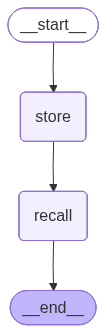

In [75]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [ ]:
state = {"query":""}
while True:
    user = input("You: ")
    if user.lower()=="q":
        break
    state["query"]=user
    state = app.invoke(state)
    print("Bot:",state["response"])

You:  remember my name is shraddha


Bot: I'll remember: my name is shraddha


You:  remember i love AIML


Bot: I'll remember: i love AIML


You:  remember i hate ECE


...

Bot: I'll remember: i am learning langgraph


You:  show memories


Bot: Your memories:
1.my name is shraddha
2.i hate ECE
3.i love aiml especially genai
4.i am learning langgraph


You:  delete my name


Bot: Deleted memory: my name is shraddha


In [77]:
import os
print(os.getcwd())

C:\Users\Shraddha
